# Claims Simulator - Feature Definition and Latent Risk Builder

This notebook demonstrates how to generate synthetic insurance features and build composite latent risk variables.

## 1. Import Required Libraries

Import necessary libraries for distribution sampling and data manipulation.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force fresh import (useful during development; safe to remove once stable)
import sys, importlib
# Remove all claimssimulator entries so they are re-imported cleanly
for key in [k for k in sys.modules if k.startswith('claimssimulator')]:
    del sys.modules[key]
import claimssimulator as csim

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Define Feature Specifications

Features are defined as a **list** of `Feature` and `DerivedFeature` dataclasses.  
Dependencies must appear **before** the features that reference them.

### Feature types

**Basic feature** — sample from a distribution:
```python
csim.Feature('vehicle_age', csim.Uniform(low=0, high=20))
```

**With a simple transform** — post-process the sampled values:
```python
csim.Feature('age', csim.LogNormal(mean=3.5, sigma=0.2),
             csim.Transform(lambda x: x + 18))
```

**With a dependent transform** — transform using other features:
```python
csim.Feature('driving_experience_years', csim.Gamma(shape=2, scale=5),
             csim.DependentTransform(
                 lambda x, age: np.clip(x, 0, age - 18),
                 dependencies=('age',)))
```

**With dependent distribution parameters** — distribution parameters can reference other columns by name:
```python
# income's underlying mean depends on age
csim.Feature('income', csim.LogNormal(mean='log_income_mu', sigma=0.3))

# claim severity scales with risk_score
csim.Feature('claim_severity', csim.Gamma(shape=2.0, scale='risk_score'))

# can also combine with a transform
csim.Feature('x', csim.Normal(loc='mu_col', scale='sigma_col'),
             csim.Transform(lambda x: np.clip(x, 0, None)))
```

**Derived feature** — pure function of other features (no random sampling):
```python
csim.DerivedFeature('age_at_first_license',
                    function=lambda age, exp: age - exp,
                    dependencies=('age', 'driving_experience_years'))
```

### Supported distributions

| Dataclass | Parameters |
|-----------|------------|
| `Normal` | `loc`, `scale` |
| `LogNormal` | `mean`, `sigma` |
| `LogNormalMeanStd` | `mean`, `std` |
| `Gamma` | `shape`, `scale` |
| `GammaMeanStd` | `mean`, `std` |
| `Beta` | `a`, `b` |
| `BetaMeanConcentration` | `mean`, `concentration` |
| `Uniform` | `low`, `high` |
| `Exponential` | `scale` |
| `Poisson` | `lam` |
| `NegativeBinomial` | `n`, `p` |
| `Categorical` | `probabilities`, `labels` (optional) |

> **Tip:** Every numeric parameter above accepts either a `float` literal or a `str` column name for element-wise (dependent) sampling.

In [36]:
# Define feature specifications for an insurance policy dataset
feature_spec = [
    # Demographic features
    csim.Feature('age', csim.LogNormal(mean=3.5, sigma=0.2),
                 csim.Transform(lambda x: x + 18)),
    csim.Feature('gender', csim.Categorical(
        probabilities=[0.5, 0.5],
        labels=['Male', 'Female'],
    )),

    # Driving / Experience features
    csim.Feature('driving_experience_years', csim.Gamma(shape=2, scale=5),
                 csim.DependentTransform(
                     lambda x, age: np.clip(x, 0, age - 18),
                     dependencies=('age',),
                 )),
    csim.DerivedFeature('age_at_first_license',
                        function=lambda age, exp: age - exp,
                        dependencies=('age', 'driving_experience_years')),
    csim.Feature('number_of_previous_claims', csim.Poisson(lam=1.5)),

    # Vehicle features
    csim.Feature('vehicle_age', csim.Uniform(low=0, high=20)),
    csim.Feature('annual_mileage', csim.LogNormal(mean=10.5, sigma=0.5)),
    csim.Feature('vehicle_type', csim.Categorical(
        probabilities=[0.5, 0.3, 0.2],
        labels=['Sedan', 'SUV', 'Truck'],
    )),

    # Risk-related features
    csim.Feature('prior_accidents', csim.NegativeBinomial(n=5, p=0.7)),

    # Contract duration
    csim.Feature('contract_duration_years', csim.Exponential(scale=3),
                 csim.Transform(lambda x: np.clip(x, 1, 10))),
]

## 3. Generate Synthetic Features

Use the FeatureDefinition class to generate synthetic data according to the specifications.

In [37]:
# Create feature generator and generate data
feature_gen = csim.FeatureDefinition(feature_spec)
n_samples = 5000

features_df = feature_gen.generate(n_samples=n_samples, random_seed=42)

print(f"Generated {n_samples} samples with {len(features_df.columns)} features")
print(f"\nDataframe shape: {features_df.shape}")
print(f"\nFirst few rows:")
print(features_df.head(10))
print(f"\nBasic statistics:")
print(features_df.describe())

Generated 5000 samples with 10 features

Dataframe shape: (5000, 10)

First few rows:
         age  gender  driving_experience_years  age_at_first_license  \
0  53.196386    Male                  3.241793             49.954594   
1  44.896689    Male                  8.418788             36.477900   
2  56.478138  Female                  4.914979             51.563160   
3  57.969351  Female                 12.905780             45.063571   
4  40.416403    Male                  7.544703             32.871699   
5  43.522594    Male                 22.592707             20.929887   
6  51.973068    Male                  2.374665             49.598402   
7  49.085811  Female                 17.389053             31.696759   
8  51.004363  Female                  7.722656             43.281707   
9  45.921338    Male                  7.962211             37.959127   

   number_of_previous_claims  vehicle_age  annual_mileage vehicle_type  \
0                          2    10.263937    26

## 4. Visualize Feature Distributions

Use the standalone `visualize_features()` and `analyze_feature()` helpers to examine the generated data.

- **`csim.visualize_features(df, ...)`** — grid of histograms (numeric) and bar charts (categorical) for every column (or a selected subset).
- **`csim.analyze_feature(df, feature, ...)`** — two-panel view: histogram + correlation bar chart for a single feature.

Both accept `vlines` (e.g. `['mean', 'median', 'perc5', 'perc95']`) to overlay summary statistics on numeric features.

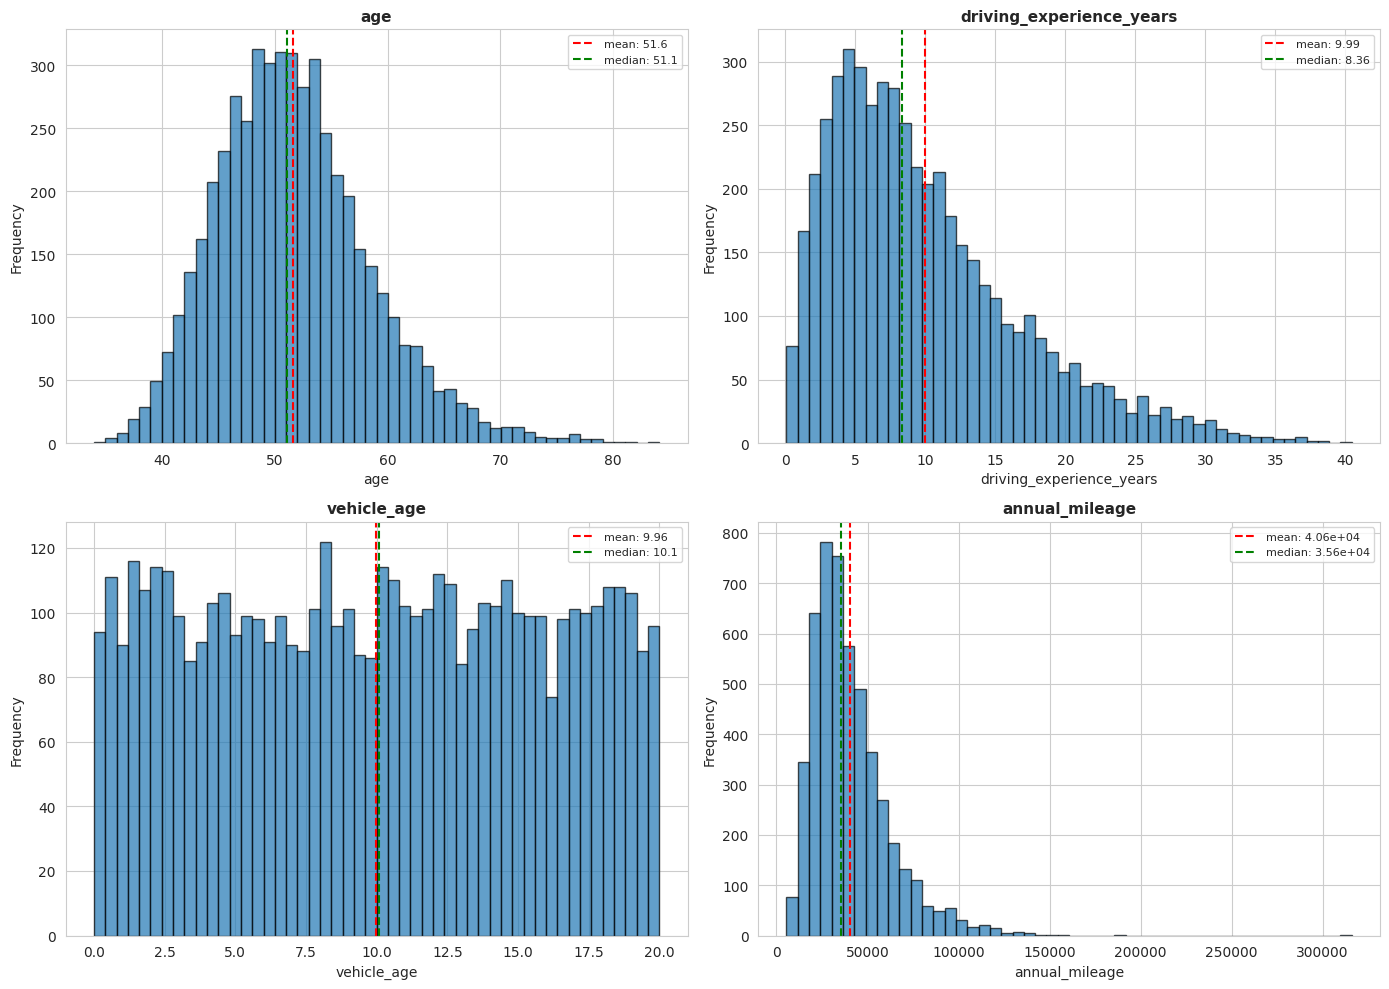

In [29]:
# Visualize continuous features using the built-in helper
continuous_features = ['age', 'driving_experience_years', 'vehicle_age', 'annual_mileage']

fig = csim.visualize_features(
    features_df,
    features=continuous_features,
    n_bins=50,
    vlines=['mean', 'median'],
    figsize_per_ax=(7, 5),
)
plt.show()

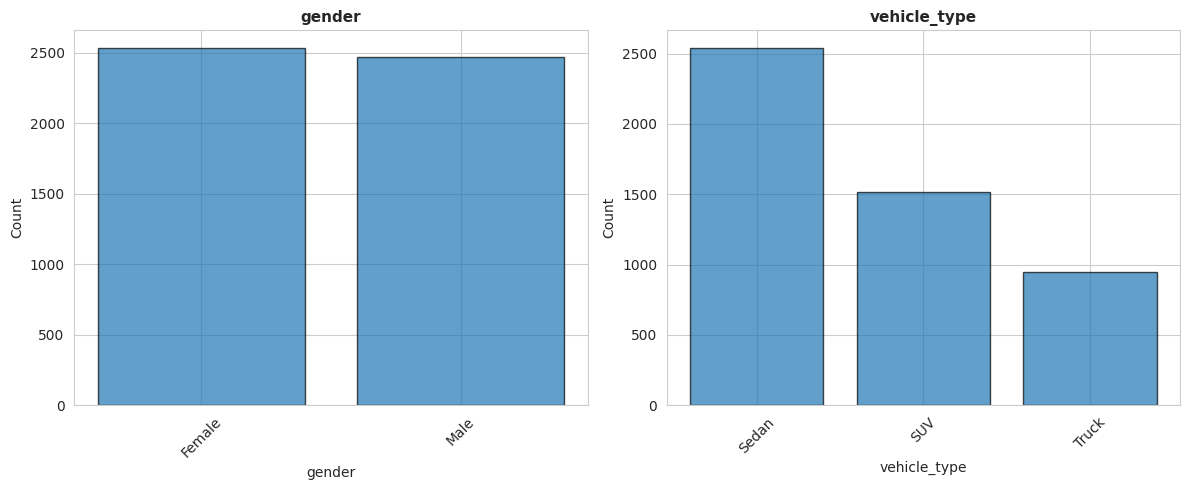

In [30]:
# Visualize categorical features using the built-in helper (now supports categoricals)
categorical_features = ['gender', 'vehicle_type']

fig = csim.visualize_features(
    features_df,
    features=categorical_features,
    figsize_per_ax=(6, 5),
)
plt.show()

## 4b. Dependent Distributions — Distribution Parameters from Other Columns

Any numeric distribution parameter can be replaced by a **string** that names a
previously generated column.  The distribution is then sampled **element-wise**:
each row uses its own parameter value.

This is useful for modelling hierarchical / conditional relationships, e.g.:
- Income distribution whose mean depends on age
- Claim severity whose scale depends on a risk score
- Heterogeneous Poisson counts where the rate varies per policy

In [ ]:
# Example: income distribution whose underlying mean depends on age
dependent_spec = [
    # Age as before
    csim.Feature('age', csim.LogNormal(mean=3.5, sigma=0.2),
                 csim.Transform(lambda x: x + 18)),

    # Derive a log-income mean from age (older → higher mean income)
    csim.DerivedFeature('log_income_mu',
                        function=lambda age: 9.5 + 0.02 * age,
                        dependencies=('age',)),

    # Income sampled per-row: each person's LogNormal mean comes from their own age
    csim.Feature('income', csim.LogNormal(mean='log_income_mu', sigma=0.3)),

    # Risk score (constant shape, but scale varies per row)
    csim.Feature('risk_score', csim.Uniform(low=0.5, high=5.0)),
    csim.Feature('claim_severity', csim.Gamma(shape=2.0, scale='risk_score')),
]

dep_gen = csim.FeatureDefinition(dependent_spec)
dep_df = dep_gen.generate(n_samples=10_000, random_seed=42)

print("Dependent distribution example — shape:", dep_df.shape)
print(dep_df[['age', 'log_income_mu', 'income', 'risk_score', 'claim_severity']].describe().round(2))

# Verify: older people should have higher income
young = dep_df[dep_df['age'] < 40]['income'].mean()
old = dep_df[dep_df['age'] >= 50]['income'].mean()
print(f"\nMean income (age < 40): ${young:,.0f}")
print(f"Mean income (age ≥ 50): ${old:,.0f}")
print(f"Ratio: {old / young:.2f}x")

# Verify: higher risk_score → higher claim severity
low_risk = dep_df[dep_df['risk_score'] < 2.0]['claim_severity'].mean()
high_risk = dep_df[dep_df['risk_score'] > 4.0]['claim_severity'].mean()
print(f"\nMean severity (risk < 2): {low_risk:.2f}")
print(f"Mean severity (risk > 4): {high_risk:.2f}")

In [ ]:
# Visualize dependent distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: age vs income (log scale)
axes[0].scatter(dep_df['age'], dep_df['income'], alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Age', fontsize=12)
axes[0].set_ylabel('Income', fontsize=12)
axes[0].set_yscale('log')
axes[0].set_title('Income ~ LogNormal(mean=f(age))', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: risk_score vs claim_severity
axes[1].scatter(dep_df['risk_score'], dep_df['claim_severity'], alpha=0.1, s=5, color='coral')
axes[1].set_xlabel('Risk Score', fontsize=12)
axes[1].set_ylabel('Claim Severity', fontsize=12)
axes[1].set_title('Severity ~ Gamma(shape=2, scale=risk_score)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Add a Risk Component via FormulaFeature

A `FormulaFeature` defines a derived column as a formula over existing features.  
It is evaluated with `pd.DataFrame.eval()` after all its dependencies have been generated.

```python
csim.FormulaFeature(
    name='profile_risk',
    formula='{beta_age} * age + {beta_exp} * driving_experience_years',
    parameters={'beta_age': 0.02, 'beta_exp': -0.03},
    mean=0.25,          # optional: rescale so the column has this mean
)
```

Because `FormulaFeature` is just another element of the feature spec list, features **and** risk are generated together in a single `FeatureDefinition.generate()` call.

In [38]:
# Append a FormulaFeature for profile risk to the existing feature spec
feature_spec_with_risk = feature_spec + [
    csim.FormulaFeature(
        name='profile_risk',
        formula='{beta_age} * age + {beta_experience} * driving_experience_years '
                '+ {beta_vehicle_age} * vehicle_age + {beta_prior_accidents} * prior_accidents',
        parameters={
            'beta_age': 0.02,
            'beta_experience': -0.03,
            'beta_vehicle_age': 0.01,
            'beta_prior_accidents': 0.5,
        },
        mean=0.25,  # Rescale so the column has this mean
    ),
]

# Generate features + risk in one call
feature_gen_with_risk = csim.FeatureDefinition(feature_spec_with_risk)
risk_df = feature_gen_with_risk.generate(n_samples=n_samples, random_seed=42)

print("Features + risk generated in a single pass!")
print(f"\nShape: {risk_df.shape}")
print(f"\nFirst few rows:")
print(risk_df[['age', 'driving_experience_years', 'vehicle_age', 'prior_accidents', 'profile_risk']].head(10))
print(f"\nProfile risk statistics:")
print(f"  Mean: {risk_df['profile_risk'].mean():.4f}")
print(f"  Median: {risk_df['profile_risk'].median():.4f}")
print(f"  Std: {risk_df['profile_risk'].std():.4f}")

Features + risk generated in a single pass!

Shape: (5000, 11)

First few rows:
         age  driving_experience_years  vehicle_age  prior_accidents  \
0  53.196386                  3.241793    10.263937                2   
1  44.896689                  8.418788     4.698243                2   
2  56.478138                  4.914979    13.992717                4   
3  57.969351                 12.905780    16.854192                0   
4  40.416403                  7.544703     5.836320                3   
5  43.522594                 22.592707    18.269488                1   
6  51.973068                  2.374665    14.938073                0   
7  49.085811                 17.389053    19.762818                1   
8  51.004363                  7.722656     3.974086                5   
9  45.921338                  7.962211     9.230941                3   

   profile_risk  
0      0.272078  
1      0.222514  
2      0.410492  
3      0.123692  
4      0.281418  
5      0.115095  
6

## 6. Analyze Risk Component Distribution

Use `csim.analyze_feature()` to examine the risk component's distribution alongside its associations with every other numeric feature in a single two-panel figure.

The `association` parameter controls the measure shown in the right panel:

| Value | Measure |
|-------|---------|
| `'pearson'` *(default)* | Pearson linear correlation |
| `'spearman'` | Spearman rank correlation |
| `'kendall'` | Kendall's τ rank correlation |
| `'mutual_info'` | Mutual information (requires scikit-learn) |
| `'hoeffding'` | Hoeffding's D non-parametric dependence |

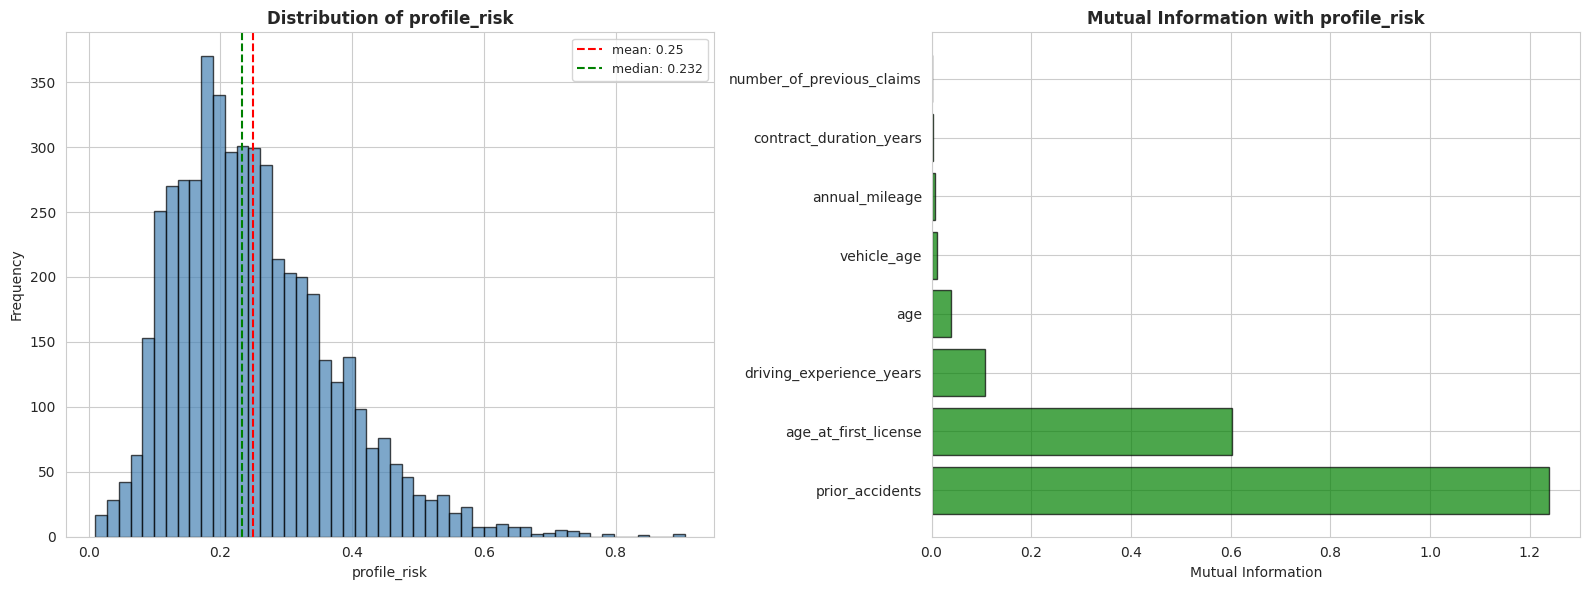

In [42]:
# Same analysis with Spearman rank correlation
fig = csim.analyze_feature(
    risk_df,
    'profile_risk',
    n_bins=50,
    vlines=['mean', 'median'],
    association='mutual_info',
)
plt.show()

## 7. Simulate Claims Data

Generate claims data suitable for training piecewise exponential proportional hazards models. Each contract is split into multiple rows (images) based on claim events:

- **No claim**: One row with `exposure = min(max_exposure, remaining_time)`, `claim = 0`
- **Claim occurs**: Row with `exposure = time_to_claim`, `claim = 1`, then new row continues

This format allows modeling time-varying hazards and is standard for survival analysis.

In [33]:
# Initialize claims simulator with Poisson process
claim_simulator = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': 'profile_risk'},  # Map 'rate' parameter to 'profile_risk' column
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    claim_counter = 'past_claims',
    renewal_mode='contract_end',
    random_seed=42,
    
)

# Simulate claims using Poisson process
claim_df = claim_simulator.simulate(risk_df)

print("Claims simulated successfully!")
print(f"\nOriginal contracts: {len(risk_df)}")
print(f"Generated rows (images): {len(claim_df)}")
print(f"Average rows per contract: {len(claim_df) / len(risk_df):.2f}")
print(f"\nTotal claims: {claim_df['claim'].sum()}")
print(f"Claim frequency: {claim_df['claim'].mean():.4f}")
print(f"Claim rate (claims/exposure): {claim_df['claim'].sum()/claim_df['exposure'].sum():.4f}")
print(f"Expected rate: {risk_df['profile_risk'].mean():.4f}")
print(f"\nFirst few rows:")
claim_df[['age', 'profile_risk', 'contract_duration_years', 'exposure', 'past_claims', 'claim', 'start_time', 'end_time']].head(15)

Claims simulated successfully!

Original contracts: 5000
Generated rows (images): 20837
Average rows per contract: 4.17

Total claims: 3793
Claim frequency: 0.1820
Claim rate (claims/exposure): 0.2484
Expected rate: 0.2500

First few rows:


,age,profile_risk,contract_duration_years,exposure,past_claims,claim,start_time,end_time
0,53.196386,0.272078,1.000000,1.000000,0,0,0.000000,1.000000
1,44.896689,0.222514,1.112675,1.000000,0,0,0.000000,1.000000
2,44.896689,0.222514,1.112675,0.112675,0,0,1.000000,1.112675
3,56.478138,0.410492,2.886076,1.000000,0,0,0.000000,1.000000
4,56.478138,0.410492,2.886076,0.413223,0,1,1.000000,1.413223
5,56.478138,0.410492,2.886076,0.413153,1,1,1.413223,1.826376
6,56.478138,0.410492,2.886076,0.145773,2,1,1.826376,1.972150
7,56.478138,0.410492,2.886076,0.027850,3,0,1.972150,2.000000
8,56.478138,0.410492,2.886076,0.886076,3,0,2.000000,2.886076
9,57.969351,0.123692,1.876631,1.000000,0,0,0.000000,1.000000


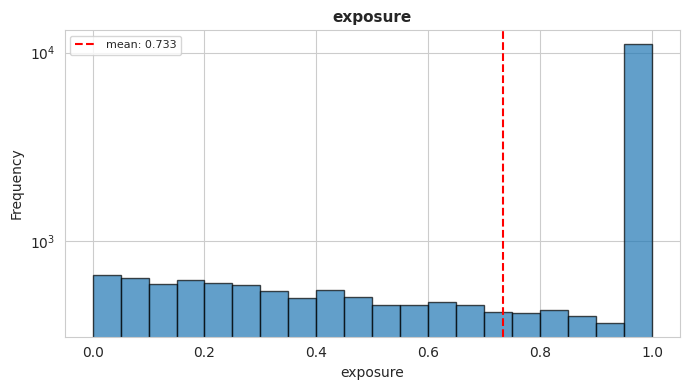

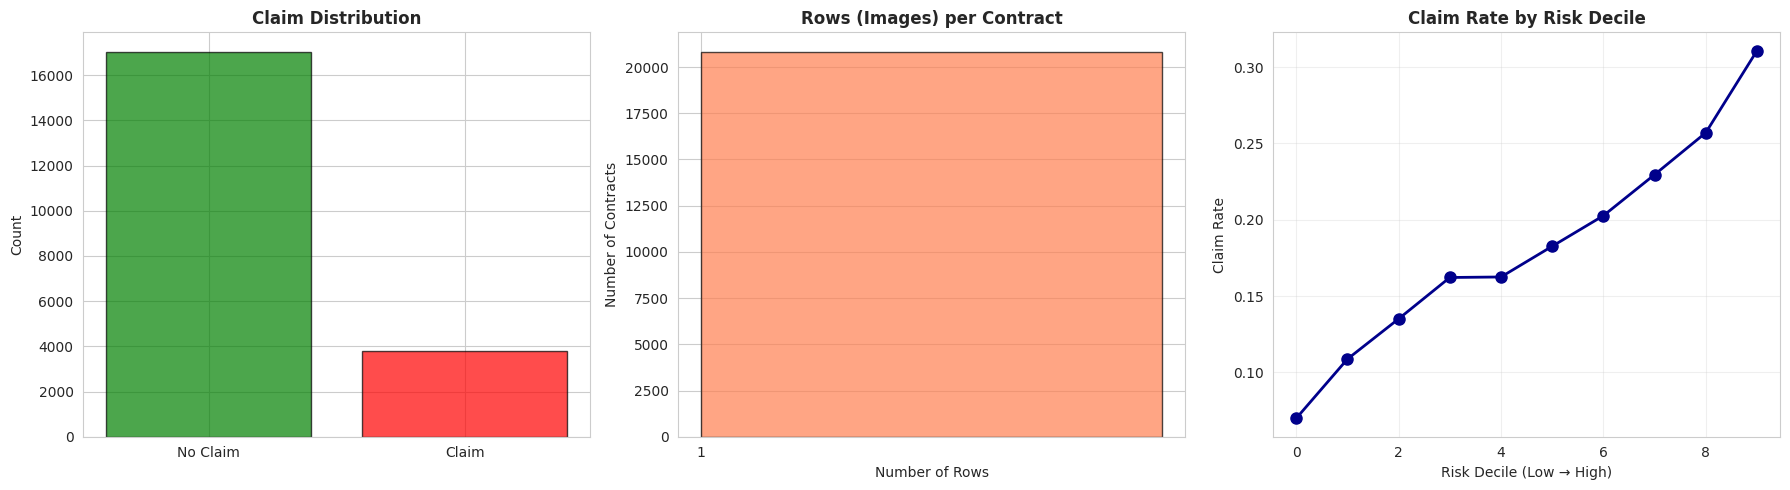

In [34]:
# ── Exposure distribution using the built-in helper ──
fig = csim.visualize_features(
    claim_df,
    features=['exposure'],
    n_bins=20,
    vlines=['mean'],
    yscale='log',
    ncols=1,
    figsize_per_ax=(7, 4),
)
plt.show()

# ── Domain-specific claims visualizations ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Claim vs No Claim
claim_counts = claim_df['claim'].value_counts()
axes[0].bar(['No Claim', 'Claim'],
            [claim_counts.get(0, 0), claim_counts.get(1, 0)],
            edgecolor='black', alpha=0.7, color=['green', 'red'])
axes[0].set_title('Claim Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# 2. Rows per contract distribution
rows_per_contract = claim_df.groupby(claim_df.index).size()
axes[1].hist(rows_per_contract, bins=range(1, rows_per_contract.max() + 2),
             edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Rows (Images) per Contract', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Rows')
axes[1].set_ylabel('Number of Contracts')
axes[1].set_xticks(range(1, min(rows_per_contract.max() + 1, 20)))

# 3. Risk vs Claim Rate
risk_bins = pd.qcut(claim_df['profile_risk'], q=10, duplicates='drop')
claim_rate_by_risk = claim_df.groupby(risk_bins, observed=True)['claim'].agg(['mean', 'count'])
axes[2].plot(range(len(claim_rate_by_risk)), claim_rate_by_risk['mean'],
             marker='o', linewidth=2, markersize=8, color='darkblue')
axes[2].set_title('Claim Rate by Risk Decile', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Risk Decile (Low → High)')
axes[2].set_ylabel('Claim Rate')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Alternative: Negative Binomial Distributions

For overdispersed data, you can use Negative Binomial distributions. There are three available implementations:

1. **NegativeBinomialMixture** (Current/Gamma-Poisson Mixture): Models unobserved heterogeneity where each contract has a latent Poisson rate drawn from a Gamma distribution. Good for modeling frailty/heterogeneity in continuous time.

2. **NegativeBinomialMeanVar** (New/Proper Parameterization): Ensures that `E[claims/exposure] = rate`. Uses `overdispersion` parameter where `Var = Mean * (1 + overdispersion)`. This is the proper way to parameterize NB for count data.

3. Future: Could add discrete geometric inter-arrival times for true NB counting process.

In [ ]:
# Approach 1: NegativeBinomialMixture (Gamma-Poisson, unobserved heterogeneity)
print("=" * 70)
print("Approach 1: NegativeBinomialMixture (Gamma-Poisson Mixture)")
print("=" * 70)
risk_df_nb1 = risk_df.copy()
risk_df_nb1['dispersion'] = 0.5  # Dispersion parameter for gamma distribution

claim_simulator_nb1 = csim.ClaimsSimulator(
    generator='NegativeBinomialMixture',
    param_columns={'rate': 'profile_risk', 'dispersion': 'dispersion'},
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=41
)
claim_df_nb1 = claim_simulator_nb1.simulate(risk_df_nb1)

print(f"Total rows: {len(claim_df_nb1)}")
print(f"Total claims: {claim_df_nb1['claim'].sum()}")
print(f"Observed claim rate: {claim_df_nb1['claim'].sum()/claim_df_nb1['exposure'].sum():.4f}")
print(f"Expected (not guaranteed to match): {risk_df['profile_risk'].mean():.4f}")
print()

# Approach 2: NegativeBinomialMeanVar (Proper NB parameterization)
print("=" * 70)
print("Approach 2: NegativeBinomialMeanVar (Proper Parameterization)")
print("=" * 70)
risk_df_nb2 = risk_df.copy()
risk_df_nb2['overdispersion'] = 0.5  # Var = Mean * (1 + overdispersion)

claim_simulator_nb2 = csim.ClaimsSimulator(
    generator='NegativeBinomialMeanVar',
    param_columns={'rate': 'profile_risk', 'overdispersion': 'overdispersion'},
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=41
)
claim_df_nb2 = claim_simulator_nb2.simulate(risk_df_nb2)

print(f"Total rows: {len(claim_df_nb2)}")
print(f"Total claims: {claim_df_nb2['claim'].sum()}")
print(f"Observed claim rate: {claim_df_nb2['claim'].sum()/claim_df_nb2['exposure'].sum():.4f}")
print(f"Expected (should be close): {risk_df['profile_risk'].mean():.4f}")
print()

# Comparison with Poisson
print("=" * 70)
print("Comparison Summary")
print("=" * 70)
print(f"Poisson claim rate:        {claim_df['claim'].sum()/claim_df['exposure'].sum():.4f}")
print(f"NB Mixture claim rate:     {claim_df_nb1['claim'].sum()/claim_df_nb1['exposure'].sum():.4f}")
print(f"NB MeanVar claim rate:     {claim_df_nb2['claim'].sum()/claim_df_nb2['exposure'].sum():.4f}")
print(f"Target rate:               {risk_df['profile_risk'].mean():.4f}")
print()
print("Note: NegativeBinomialMeanVar is designed so E[claims/exposure] = rate")
print("      NegativeBinomialMixture models heterogeneity but doesn't guarantee this")

Approach 1: NegativeBinomialMixture (Gamma-Poisson Mixture)
Total rows: 19396
Total claims: 3532
Observed claim rate: 0.2302
Expected (not guaranteed to match): 0.2500

Approach 2: NegativeBinomialMeanVar (Proper Parameterization)
Total rows: 19396
Total claims: 3532
Observed claim rate: 0.2302
Expected (not guaranteed to match): 0.2500

Approach 2: NegativeBinomialMeanVar (Proper Parameterization)
Total rows: 19396
Total claims: 3532
Observed claim rate: 0.2302
Expected (should be close): 0.2500

Comparison Summary
Poisson claim rate:        0.2501
NB Mixture claim rate:     0.2302
NB MeanVar claim rate:     0.2302
Target rate:               0.2500

Note: NegativeBinomialMeanVar is designed so E[claims/exposure] = rate
      NegativeBinomialMixture models heterogeneity but doesn't guarantee this
Total rows: 19396
Total claims: 3532
Observed claim rate: 0.2302
Expected (should be close): 0.2500

Comparison Summary
Poisson claim rate:        0.2501
NB Mixture claim rate:     0.2302
NB M

## Summary: Three Claims Generation Approaches

### 1. **Poisson** (`generator='Poisson'`)
**Use case**: Simple homogeneous Poisson process

**Inter-arrival times**: Exponential with rate λ

**Parameters**: `{'rate': 'column_name'}`

**Properties**:
- `E[claims/exposure] = rate`
- `Var[claims/exposure] = rate` (equidispersion)
- Time to next claim: `~Exponential(1/rate)`

**When to use**: When claim events are independent and occur at a constant average rate

---

### 2. **NegativeBinomialMixture** (`generator='NegativeBinomialMixture'`)
**Use case**: Modeling unobserved heterogeneity / frailty

**Inter-arrival times**: Each contract has a latent rate drawn from Gamma, then uses Exponential inter-arrival

**Parameters**: `{'rate': 'mean_column', 'dispersion': 'dispersion_column'}`

**Properties**:
- Latent rate ~ `Gamma(shape=1/dispersion, scale=rate*dispersion)`
- `E[latent_rate] = rate`
- `Var[latent_rate] = rate² * dispersion`
- Then time to claim ~ `Exponential(1/latent_rate)`

**When to use**: When you believe each contract has its own underlying risk level (frailty), but you don't observe it directly. Models continuous-time heterogeneity.

**Note**: The observed `E[claims/exposure]` will NOT exactly equal `rate` due to non-linear transformation

---

### 3. **NegativeBinomialMeanVar** (`generator='NegativeBinomialMeanVar'`) ⭐ **NEW**
**Use case**: Overdispersed counts with proper mean-variance relationship

**Inter-arrival times**: Similar to Mixture but parameterized to preserve the mean

**Parameters**: `{'rate': 'rate_column', 'overdispersion': 'overdispersion_column'}`

**Properties**:
- `E[claims/exposure] = rate` ✓ (guaranteed by construction)
- `Var[claims] = Mean * (1 + overdispersion)`
- Shape parameter: `r = 1/overdispersion`
- Latent rate ~ `Gamma(r, rate * overdispersion)`

**When to use**: When you want overdispersion but need `E[claims/exposure]` to match your risk model predictions. This is the **proper parameterization** for NB regression-style models.

**Key advantage**: The expected claim rate matches your input `rate` column, making it ideal for validation and interpretation.

---

### Choosing the Right Approach

| Scenario | Recommended Generator |
|----------|----------------------|
| Simple Poisson process, no overdispersion | `Poisson` |
| Modeling unobserved contract-level heterogeneity | `NegativeBinomialMixture` |
| Overdispersed counts, need E[claims] = rate | `NegativeBinomialMeanVar` ⭐ |
| True discrete-time NB counting process | *Future: Geometric inter-arrival* |

### Mathematical Details

**NegativeBinomialMeanVar Parameterization**:

Given:
- Mean claim rate: μ
- Overdispersion: α (where Var = μ(1 + α))

The NB distribution parameters are:
- r = 1/α (shape/size parameter)
- The latent rate is drawn from: Gamma(shape=r, scale=μα)

This ensures:
- E[latent_rate] = r × (μα) = μ ✓
- Var[latent_rate] = r × (μα)² = μ²α
- Therefore: E[claims/time] = μ as desired!

## Advanced Feature: Time-Varying Risk Parameters

The `ClaimsSimulator` supports time-varying risk parameters where the risk can change over the lifetime of a contract. This is useful for modeling scenarios where:

- Risk increases with contract age (e.g., vehicle deterioration)
- Risk decreases over time (e.g., driver experience improvement)
- Risk follows complex patterns (e.g., seasonal effects)

### How it works:

Instead of providing a static column name in `param_columns`, you can provide a **callable function** that takes time `t` as input:

```python
param_columns = {
    'rate': lambda t: 1.0 + 0.5 * t  # Risk increases linearly with time
}
```

You can also mix static and time-varying parameters:

```python
param_columns = {
    'rate': lambda t: base_rate * (1 + t/10),  # Time-varying
    'dispersion': 'dispersion_column'           # Static from DataFrame
}
```

### Time representation:

- `t` represents **global time** since the contract start
- If `start_time_column` is provided, then `t = start_time + elapsed_time`
- Parameters are evaluated at each interval boundary (piecewise constant within intervals)

In [ ]:
# Example 1: Time-varying risk - Increasing rate over time
print("=" * 70)
print("Example 1: Time-Varying Risk - Rate increases with contract age")
print("=" * 70)

# Create a simple dataset with longer contracts
tv_df = pd.DataFrame({
    'contract_id': range(100),
    'base_risk': np.random.uniform(0.5, 1.5, 100),
    'contract_duration_years': np.random.uniform(3, 5, 100)
})

# Risk doubles over 5 years: rate(t) = 0.5 + 0.2*t
# At t=0: rate = 0.5
# At t=5: rate = 1.5
tv_simulator = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': lambda t: 0.5 + 0.2 * t},
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=42
)

tv_claim_df = tv_simulator.simulate(tv_df)

print(f"\nContracts simulated: {len(tv_df)}")
print(f"Total rows generated: {len(tv_claim_df)}")
print(f"Total claims: {tv_claim_df['claim'].sum()}")
print(f"Overall claim rate: {tv_claim_df['claim'].sum()/tv_claim_df['exposure'].sum():.4f}")

# Analyze claim rate by contract year
tv_claim_df['contract_year'] = tv_claim_df['start_time'].apply(lambda x: int(x))
claim_rate_by_year = tv_claim_df.groupby('contract_year').agg({
    'claim': ['sum', 'mean'],
    'exposure': 'sum'
})
claim_rate_by_year['rate'] = claim_rate_by_year[('claim', 'sum')] / claim_rate_by_year[('exposure', 'sum')]

print("\nClaim rate by contract year:")
print(claim_rate_by_year)
print("\nNote: Claim rate increases with contract age as expected!")

# Compare with static risk
static_simulator = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': lambda t: 0.5 + 0.2 * 2.5},  # Fixed at mid-point
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=42
)
static_claim_df = static_simulator.simulate(tv_df)

print(f"\nComparison with static risk (rate=1.0):")
print(f"Time-varying claims: {tv_claim_df['claim'].sum()}")
print(f"Static claims: {static_claim_df['claim'].sum()}")
print(f"Difference: {tv_claim_df['claim'].sum() - static_claim_df['claim'].sum()} more claims with time-varying risk")

Example 1: Time-Varying Risk - Rate increases with contract age


ValueError: Column '<function <lambda> at 0x76c13d805bc0>' (for parameter 'rate') not found in DataFrame

In [ ]:
# Example 2: Mixed static and time-varying parameters
print("\n" + "=" * 70)
print("Example 2: Mixed Parameters - Time-varying rate with static dispersion")
print("=" * 70)

# Add dispersion column to the dataframe
tv_df_nb = tv_df.copy()
tv_df_nb['dispersion'] = 0.5

# Use NegativeBinomialMixture with time-varying rate but static dispersion
mixed_simulator = csim.ClaimsSimulator(
    generator='NegativeBinomialMixture',
    param_columns={
        'rate': lambda t: 0.8 + 0.15 * t,  # Time-varying: increases from 0.8 to ~1.55
        'dispersion': 'dispersion'          # Static: from DataFrame column
    },
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=42
)

mixed_claim_df = mixed_simulator.simulate(tv_df_nb)

print(f"\nContracts simulated: {len(tv_df_nb)}")
print(f"Total rows generated: {len(mixed_claim_df)}")
print(f"Total claims: {mixed_claim_df['claim'].sum()}")
print(f"Overall claim rate: {mixed_claim_df['claim'].sum()/mixed_claim_df['exposure'].sum():.4f}")

print("\nParameters used:")
print("  rate(t): 0.8 + 0.15*t (time-varying)")
print("  dispersion: 0.5 (static from column)")
print("\nNote: This models contracts where the base risk increases over time")
print("      but the dispersion (unobserved heterogeneity) stays constant.")

In [ ]:
# Example 3: start_time_column - Contracts starting at different times
print("\n" + "=" * 70)
print("Example 3: start_time_column - Staggered contract starts")
print("=" * 70)

# Create contracts that start at different times
staggered_df = pd.DataFrame({
    'contract_id': range(5),
    'start_time': [0.0, 2.0, 4.0, 6.0, 8.0],  # Contracts start every 2 years
    'contract_duration_years': [5.0] * 5  # All last 5 years
})

print("Contract timeline:")
for _, row in staggered_df.iterrows():
    print(f"  Contract {row['contract_id']}: t={row['start_time']:.1f} to t={row['start_time'] + row['contract_duration_years']:.1f}")

# Risk increases globally over time: rate(t) = 0.5 + 0.1*t
# Later contracts experience higher overall risk
staggered_simulator = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': lambda t: 0.5 + 0.1 * t},
    start_time_column='start_time',
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    random_seed=42
)

staggered_claim_df = staggered_simulator.simulate(staggered_df)

print("\nClaims by contract:")
for contract_id in range(5):
    contract_claims = staggered_claim_df[staggered_claim_df['contract_id'] == contract_id]
    total_claims = contract_claims['claim'].sum()
    total_exposure = contract_claims['exposure'].sum()
    start_t = staggered_df.iloc[contract_id]['start_time']
    avg_rate = 0.5 + 0.1 * (start_t + 2.5)  # Approximate mid-point rate
    print(f"  Contract {contract_id} (t={start_t:.1f}-{start_t+5:.1f}): "
          f"{total_claims} claims in {total_exposure:.1f} years "
          f"(expected rate ≈ {avg_rate:.2f})")

print("\nNote: Later contracts have more claims because they experience higher")
print("      global risk rates (rate increases from 0.5 to 1.8 over calendar time)")

In [ ]:
# Visualization: Compare static vs time-varying risk
print("\n" + "=" * 70)
print("Visualization: Static vs Time-Varying Risk Comparison")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Risk function over time
t_values = np.linspace(0, 5, 100)
rate_values = 0.5 + 0.2 * t_values

axes[0].plot(t_values, rate_values, linewidth=3, color='darkblue', label='rate(t) = 0.5 + 0.2*t')
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Static rate = 1.0')
axes[0].set_xlabel('Time (years)', fontsize=12)
axes[0].set_ylabel('Claim Rate', fontsize=12)
axes[0].set_title('Risk Function Over Contract Lifetime', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.4, 1.6])

# Plot 2: Claim rate by contract year (time-varying)
axes[1].bar(claim_rate_by_year.index, claim_rate_by_year['rate'], 
            edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Contract Year', fontsize=12)
axes[1].set_ylabel('Observed Claim Rate', fontsize=12)
axes[1].set_title('Time-Varying: Claims by Year', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Total claims comparison
comparison_data = {
    'Time-Varying\n(rate increases)': tv_claim_df['claim'].sum(),
    'Static\n(rate = 1.0)': static_claim_df['claim'].sum()
}
colors_comp = ['darkblue', 'darkred']
axes[2].bar(comparison_data.keys(), comparison_data.values(), 
            edgecolor='black', alpha=0.7, color=colors_comp)
axes[2].set_ylabel('Total Claims', fontsize=12)
axes[2].set_title('Total Claims Comparison', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (label, value) in enumerate(comparison_data.items()):
    axes[2].text(i, value + 5, f'{int(value)}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")
print(f"Time-varying risk produces {tv_claim_df['claim'].sum() - static_claim_df['claim'].sum()} more claims")
print("because contracts spend more time in high-risk periods.")

### Practical Use Cases for Time-Varying Risk

**1. Vehicle Aging**: Risk increases as vehicles age and deteriorate
```python
param_columns = {'rate': lambda t: base_rate * (1 + 0.05 * t)}  # 5% increase per year
```

**2. Driver Experience**: Risk decreases as drivers gain experience
```python
param_columns = {'rate': lambda t: base_rate * np.exp(-0.1 * t)}  # Exponential decay
```

**3. Seasonal Effects**: Risk varies cyclically (e.g., weather-related)
```python
param_columns = {'rate': lambda t: base_rate * (1 + 0.3 * np.sin(2*np.pi*t))}  # Annual cycle
```

**4. Contract Renewal with Rate Changes**: Model contracts that continue after rate adjustments
```python
# Contract starts at year 5 with new (higher) rates
start_time_column = 'contract_start_year'
param_columns = {'rate': lambda t: 1.0 + 0.1 * t}  # Global calendar time
```

**5. Learning Effect**: Policyholders with claim_counter improving over time
```python
# Combine with claim_counter to model learning
param_columns = {'rate': lambda t: base_rate * (1 - 0.05 * min(t, 5))}  # Improves up to 5 years
```

In [ ]:
# Example 4: Decreasing risk over time (driver improvement)
print("=" * 70)
print("Example 4: Decreasing Risk - Driver improves with experience")
print("=" * 70)

# Model new drivers who improve over time
improvement_df = pd.DataFrame({
    'contract_id': range(50),
    'contract_duration_years': [5.0] * 50
})

# Risk decreases exponentially: starts at 2.0, decays to ~0.74 after 5 years
# rate(t) = 2.0 * exp(-0.2*t)
improvement_simulator = csim.ClaimsSimulator(
    generator='Poisson',
    param_columns={'rate': lambda t: 2.0 * np.exp(-0.2 * t)},
    time_to_simulate='contract_duration_years',
    max_exposure=1.0,
    claim_counter='past_claims',
    random_seed=42
)

improvement_claim_df = improvement_simulator.simulate(improvement_df)

# Analyze by contract year
improvement_claim_df['contract_year'] = improvement_claim_df['start_time'].apply(lambda x: int(x))
improvement_by_year = improvement_claim_df.groupby('contract_year').agg({
    'claim': ['sum', 'count'],
    'exposure': 'sum'
})
improvement_by_year['rate'] = improvement_by_year[('claim', 'sum')] / improvement_by_year[('exposure', 'sum')]
improvement_by_year['expected_rate'] = [2.0 * np.exp(-0.2 * (i + 0.5)) for i in range(len(improvement_by_year))]

print(f"\nTotal claims: {improvement_claim_df['claim'].sum()}")
print(f"Total contracts: {len(improvement_df)}")
print(f"\nClaim rate by year:")
print(improvement_by_year[['rate', 'expected_rate']])

# Visualize the learning curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
t_vals = np.linspace(0, 5, 100)
rate_vals = 2.0 * np.exp(-0.2 * t_vals)
plt.plot(t_vals, rate_vals, linewidth=3, color='darkgreen', label='rate(t) = 2.0 * exp(-0.2*t)')
plt.scatter(improvement_by_year.index + 0.5, improvement_by_year['rate'], 
            s=100, color='red', zorder=5, label='Observed rate')
plt.xlabel('Time (years)', fontsize=12)
plt.ylabel('Claim Rate', fontsize=12)
plt.title('Risk Decreases with Driver Experience', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
yearly_claims = improvement_by_year[('claim', 'sum')].values
plt.bar(range(len(yearly_claims)), yearly_claims, edgecolor='black', alpha=0.7, color='darkgreen')
plt.xlabel('Contract Year', fontsize=12)
plt.ylabel('Total Claims', fontsize=12)
plt.title('Claims Decrease Over Time', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nNote: Risk starts high (2.0) for new drivers and decreases to ~0.74 after 5 years")
print("      This models the learning/improvement effect over time.")